# Overview

The kernel goes through

1. the preprocessing steps to load the data
2. a quick visualization of the color-space
3. training a simple CNN
4. applying the model to the test data
5. creating the RLE test data

In [2]:
import numpy as np
import pandas as pd
from glob import glob
import os
from skimage.io import imread
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
dsb_data_dir = os.path.join('.', 'input')
stage_label = 'stage1'

## Read in the labels

Load the RLE-encoded output for the training set

In [3]:
train_labels = pd.read_csv(os.path.join(dsb_data_dir, '{}_train_labels.csv'.format(stage_label)))
train_labels['EncodedPixels'] = train_labels['EncodedPixels'].map(lambda ep: [int(x) for x in ep.split(' ')])
train_labels.sample(3)

,ImageId,EncodedPixels
16768,8f27ebc74164eddfe989a98a754dcf5a9c85ef599a1321...,"[43777, 1, 44033, 4, 44289, 5, 44545, 5, 44801..."
9043,4d2cff9a0c8df3a7ef6100fda6f66e865a7670af6a1856...,"[224996, 7, 225515, 9, 226034, 11, 226553, 13,..."
5054,27c30f9011492f234e4587c9a4b53c787037d486f65882...,"[4105, 6, 4360, 8, 4615, 9, 4871, 10, 5127, 11..."


## Load in all Images

Here we load in the images and process the paths so we have the appropriate information for each image

In [5]:
all_images = glob(os.path.join(dsb_data_dir, 'stage1_*', '*', '*', '*'))
img_df = pd.DataFrame({'path': all_images})
img_id = lambda in_path: in_path.split('\\')[-3]
img_type = lambda in_path: in_path.split('\\')[-2]
img_group = lambda in_path: in_path.split('\\')[-4].split('_')[1]
img_stage = lambda in_path: in_path.split('\\')[-4].split('_')[0]
img_df['ImageId'] = img_df['path'].map(img_id)
img_df['ImageType'] = img_df['path'].map(img_type)
img_df['TrainingSplit'] = img_df['path'].map(img_type)
img_df['Stage'] = img_df['path'].map(img_group)
img_df.sample(2)

,path,ImageId,ImageType,TrainingSplit,Stage
8496,.\input\stage1_train\4590d7d47f521df62f3bcb0bf...,4590d7d47f521df62f3bcb0bf74d1bca861d94ade614d8...,masks,masks,train
11583,.\input\stage1_train\5b2ccfb94dedf2ec8797c0404...,5b2ccfb94dedf2ec8797c0404fc324888e35ab903c41bb...,masks,masks,train


In [6]:
img_df.head().iloc[0,0].split('/')

['.\\input\\stage1_test\\0114f484a16c152baa2d82fdd43740880a762c93f436c8988ac461c5c9dbe7d5\\images\\0114f484a16c152baa2d82fdd43740880a762c93f436c8988ac461c5c9dbe7d5.png']

## Create Training Data

Here we make training data and load all the images into the dataframe. We take a simplification here of grouping all the regions together (rather than keeping them distinct).

In [12]:
%%time
train_df = img_df.query('Stage=="train"')
train_rows = []
group_cols = ['Stage', 'ImageId']
for n_group, n_rows in train_df.groupby(group_cols):
    c_row = {col_name: col_value for col_name, col_value in zip(group_cols, n_group)}
    c_row['masks'] = n_rows.query('ImageType == "masks"')['path'].values.tolist()
    c_row['images'] = n_rows.query('ImageType == "images"')['path'].values.tolist()
    train_rows += [c_row]
train_img_df = pd.DataFrame(train_rows)
IMG_CHANNELS = 3
def read_and_stack(in_img_list):
    return np.sum(np.stack([imread(c_img) for c_img in in_img_list], 0), 0)/255.0
train_img_df['images'] = train_img_df['images'].map(read_and_stack).map(lambda x: x[:, :, :IMG_CHANNELS])
train_img_df['masks'] = train_img_df['masks'].map(read_and_stack).map(lambda x: x.astype(int))
train_img_df.sample(1)

CPU times: total: 3min 36s
Wall time: 14min 8s


,Stage,ImageId,masks,images
535,train,c96109cbebcf206f20035cbde414e43872074eee8d839b...,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[[0.023529411764705882, 0.023529411764705882,..."


In [10]:
img_df

,path,ImageId,ImageType,TrainingSplit,Stage
0,.\input\stage1_test\0114f484a16c152baa2d82fdd4...,0114f484a16c152baa2d82fdd43740880a762c93f436c8...,images,images,test
1,.\input\stage1_test\0999dab07b11bc85fb8464fc36...,0999dab07b11bc85fb8464fc36c947fbd8b5d6ec498173...,images,images,test
2,.\input\stage1_test\0a849e0eb15faa8a6d7329c3dd...,0a849e0eb15faa8a6d7329c3dd66aabe9a294cccb52ed3...,images,images,test
3,.\input\stage1_test\0e132f71c8b4875c3c2dd7a229...,0e132f71c8b4875c3c2dd7a22997468a3e842b46aa9bd4...,images,images,test
4,.\input\stage1_test\0ed3555a4bd48046d3b63d8baf...,0ed3555a4bd48046d3b63d8baf03a5aa97e523aa483aaa...,images,images,test
...,...,...,...,...,...
30191,.\input\stage1_train\ff599c7301daa1f783924ac8c...,ff599c7301daa1f783924ac8cbe3ce7b42878f15a39c2d...,masks,masks,train
30192,.\input\stage1_train\ff599c7301daa1f783924ac8c...,ff599c7301daa1f783924ac8cbe3ce7b42878f15a39c2d...,masks,masks,train
30193,.\input\stage1_train\ff599c7301daa1f783924ac8c...,ff599c7301daa1f783924ac8cbe3ce7b42878f15a39c2d...,masks,masks,train
30194,.\input\stage1_train\ff599c7301daa1f783924ac8c...,ff599c7301daa1f783924ac8cbe3ce7b42878f15a39c2d...,masks,masks,train


In [9]:
train_img_df

""


## Show a few images

Here we show a few images of the cells where we see there is a mixture of brightfield and fluorescence which will probably make using a single segmentation algorithm difficult

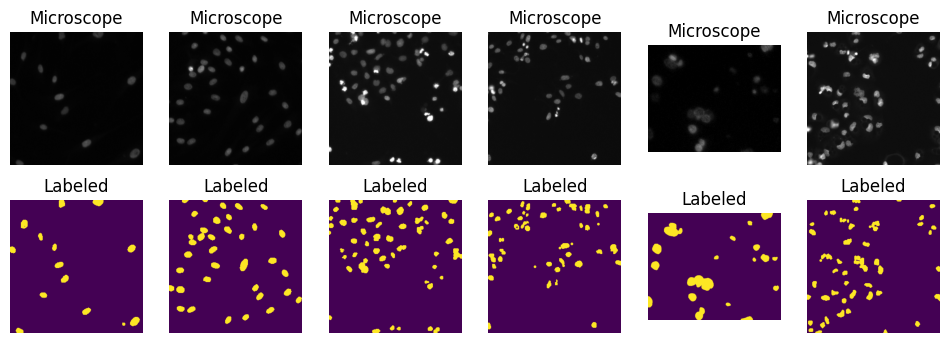

In [13]:
n_img = 6
fig, m_axs = plt.subplots(2, n_img, figsize=(12, 4))
for (_, c_row), (c_im, c_lab) in zip(train_img_df.sample(n_img).iterrows(), m_axs.T):
    c_im.imshow(c_row['images'])
    c_im.axis('off')
    c_im.set_title('Microscope')

    c_lab.imshow(c_row['masks'])
    c_lab.axis('off')
    c_lab.set_title('Labeled')

## Look at the intensity distribution

Here we look briefly at the distribution of intensity and see a few groups forming, they should probably be handled separately.

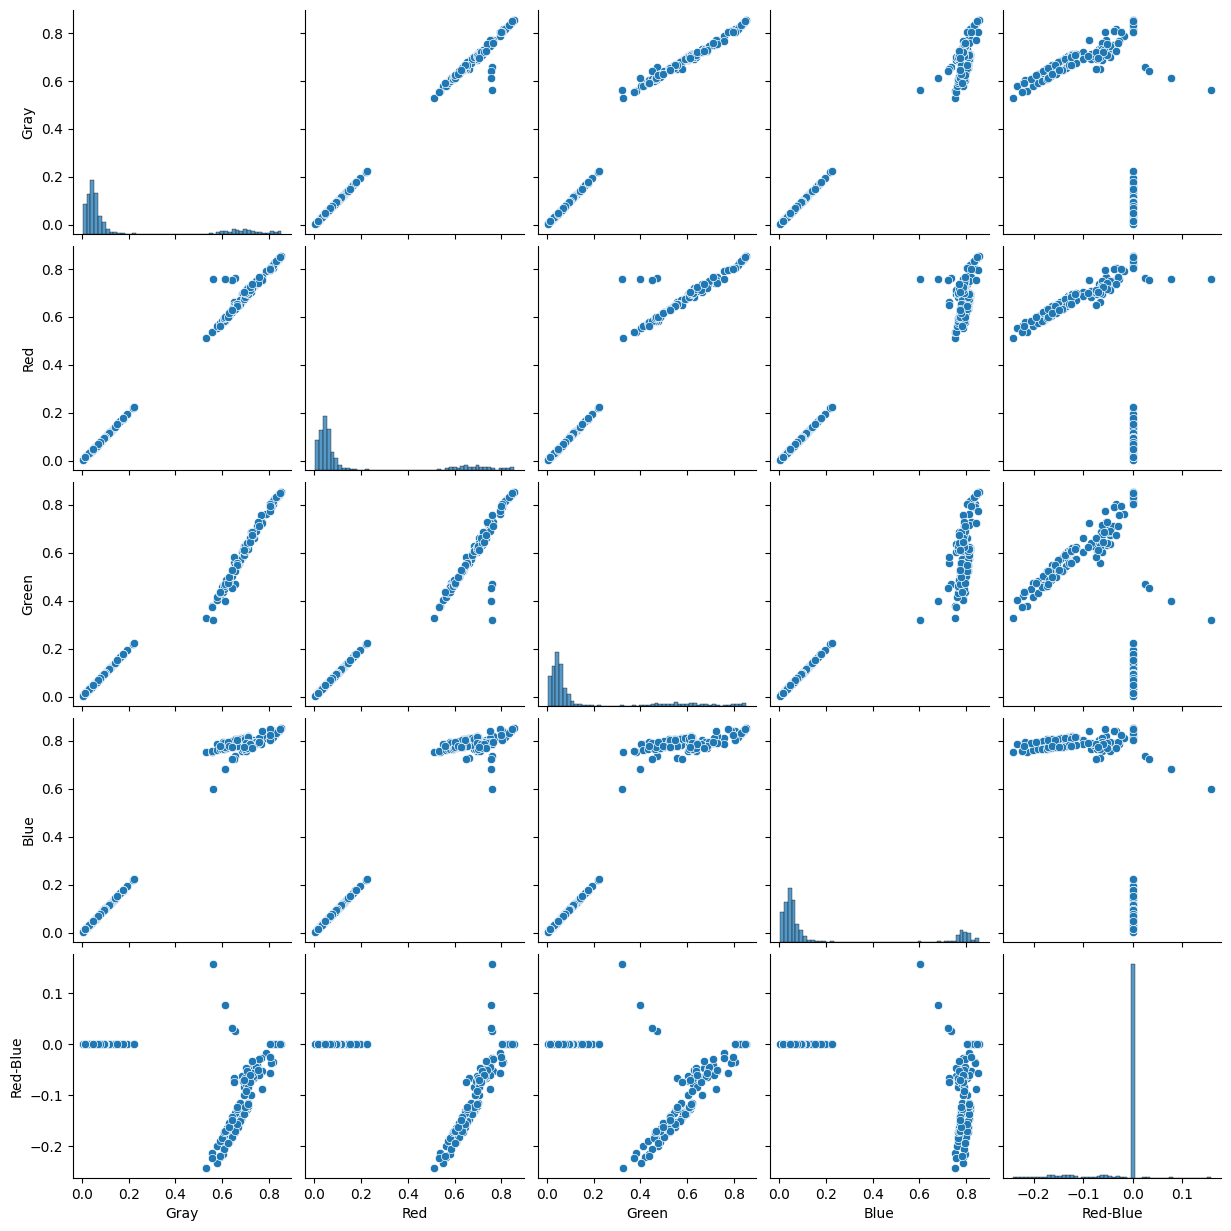

In [14]:
train_img_df['Red'] = train_img_df['images'].map(lambda x: np.mean(x[:, :, 0]))
train_img_df['Green'] = train_img_df['images'].map(lambda x: np.mean(x[:, :, 1]))
train_img_df['Blue'] = train_img_df['images'].map(lambda x: np.mean(x[:, :, 2]))
train_img_df['Gray'] = train_img_df['images'].map(lambda x: np.mean(x))
train_img_df['Red-Blue'] = train_img_df['images'].map(lambda x: np.mean(x[:, :, 0]-x[:, :, 2]))
sns.pairplot(train_img_df[['Gray', 'Red', 'Green', 'Blue', 'Red-Blue']])

## Check Dimensions

Here we show the dimensions of the data to see the variety in the input images

In [15]:
train_img_df['images'].map(lambda x: x.shape).value_counts()

images
(256, 256, 3)      334
(256, 320, 3)      112
(520, 696, 3)       92
(360, 360, 3)       91
(1024, 1024, 3)     16
(512, 640, 3)       13
(603, 1272, 3)       6
(260, 347, 3)        5
(1040, 1388, 3)      1
Name: count, dtype: int64

### Making a simple CNN

Here we make a very simple CNN just to get a quick idea of how well it works. For this we use a batch normalization to normalize the inputs. We cheat a bit with the padding to keep problems simple.

In [16]:
from keras.models import Sequential
from keras.layers import BatchNormalization, Conv2D, UpSampling2D, Lambda


In [17]:
simple_cnn = Sequential()
simple_cnn.add(BatchNormalization(input_shape=(None, None, IMG_CHANNELS), name='NormalizeInput'))
simple_cnn.add(Conv2D(8, kernel_size=(3, 3), padding='same'))
simple_cnn.add(Conv2D(8, kernel_size=(3, 3), padding='same'))

simple_cnn.add(Conv2D(16, kernel_size=(3, 3), dilation_rate=2, padding='same'))
simple_cnn.add(Conv2D(16, kernel_size=(3, 3), dilation_rate=2, padding='same'))
simple_cnn.add(Conv2D(32, kernel_size=(3, 3), dilation_rate=3, padding='same'))

simple_cnn.add(Conv2D(16, kernel_size=(1, 1), padding='same'))
simple_cnn.add(Conv2D(1, kernel_size=(1, 1), padding='same', activation='sigmoid'))
simple_cnn.summary()

c:\Users\USER\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\normalization\batch_normalization.py:181: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ NormalizeInput                  │ (None, None, None, 3)  │            12 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, None, None, 8)  │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, None, None, 8)  │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, None, None, 16) │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, None, None, 16) │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, None, None, 32) │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, None, None, 16) │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, None, None, 1)  │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,493 (37.08 KB)

 Trainable params: 9,487 (37.06 KB)

 Non-trainable params: 6 (24.00 B)

## Loss

Since we are being evaluated with intersection over union we can use the inverse of the DICE score as the loss function to optimize

In [21]:
from keras import ops

smooth = 1.
def dice_coef(y_true, y_pred):
    y_true_f = ops.reshape(ops.cast(y_true, y_pred.dtype), [-1])
    y_pred_f = ops.reshape(y_pred, [-1])
    intersection = ops.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (ops.sum(y_true_f) + ops.sum(y_pred_f) + smooth)

def dice_coef_loss(y_true, y_pred):
    return -dice_coef(y_true, y_pred)

simple_cnn.compile(optimizer='adam',
                   loss=dice_coef_loss,
                   metrics=[dice_coef, 'acc', 'mse'])

## Simple Training

Here we run a simple training, with each image being it's own batch (not a very good idea), but it keeps the code simple.

In [24]:
import tensorflow as tf

def simple_gen():
    while True:
        for _, c_row in train_img_df.iterrows():
            yield np.expand_dims(c_row['images'], 0), np.expand_dims(np.expand_dims(c_row['masks'], -1), 0)

train_ds = tf.data.Dataset.from_generator(
    simple_gen,
    output_signature=(
        tf.TensorSpec(shape=(None, None, None, IMG_CHANNELS), dtype=tf.float32),
        tf.TensorSpec(shape=(None, None, None, 1), dtype=tf.float32),
    )
)

simple_cnn.fit(train_ds,
               steps_per_epoch=train_img_df.shape[0], epochs=3)

Epoch 1/3
670/670 ━━━━━━━━━━━━━━━━━━━━ 41s 59ms/step - acc: 0.9066 - dice_coef: 0.7383 - loss: -0.7383 - mse: 0.0891
Epoch 2/3
670/670 ━━━━━━━━━━━━━━━━━━━━ 37s 55ms/step - acc: 0.9279 - dice_coef: 0.7975 - loss: -0.7975 - mse: 0.0702
Epoch 3/3
670/670 ━━━━━━━━━━━━━━━━━━━━ 36s 55ms/step - acc: 0.9302 - dice_coef: 0.8033 - loss: -0.8033 - mse: 0.0685


## Apply Model to Test

Here we apply the model to the test data

In [25]:
%%time
test_df = img_df.query('Stage=="test"')
test_rows = []
group_cols = ['Stage', 'ImageId']
for n_group, n_rows in test_df.groupby(group_cols):
    c_row = {col_name: col_value for col_name, col_value in zip(group_cols, n_group)}
    c_row['images'] = n_rows.query('ImageType == "images"')['path'].values.tolist()
    test_rows += [c_row]
test_img_df = pd.DataFrame(test_rows)

test_img_df['images'] = test_img_df['images'].map(read_and_stack).map(lambda x: x[:, :, :IMG_CHANNELS])
print(test_img_df.shape[0], 'images to process')
test_img_df.sample(1)

65 images to process
CPU times: total: 1.19 s
Wall time: 2.66 s


,Stage,ImageId,images
4,test,0ed3555a4bd48046d3b63d8baf03a5aa97e523aa483aaa...,"[[[0.054901960784313725, 0.054901960784313725,..."


In [26]:
%%time
test_img_df['masks'] = test_img_df['images'].map(lambda x: simple_cnn.predict(np.expand_dims(x, 0))[0, :, :, 0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━

## Show a few predictions

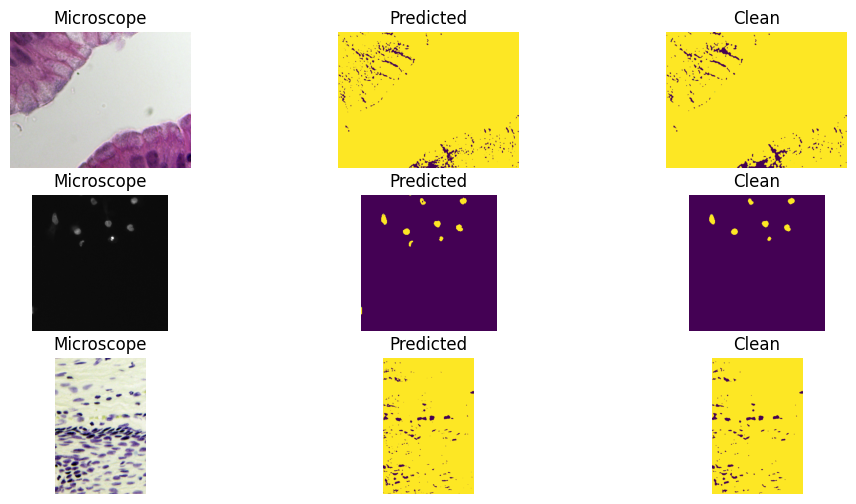

In [27]:
n_img = 3
from skimage.morphology import closing, opening, disk
def clean_img(x):
    return opening(closing(x, disk(1)), disk(3))
fig, m_axs = plt.subplots(3, n_img, figsize=(12, 6))
for (_, d_row), (c_im, c_lab, c_clean) in zip(test_img_df.sample(n_img).iterrows(), m_axs):
    c_im.imshow(d_row['images'])
    c_im.axis('off')
    c_im.set_title('Microscope')

    c_lab.imshow(d_row['masks'])
    c_lab.axis('off')
    c_lab.set_title('Predicted')

    c_clean.imshow(clean_img(d_row['masks']))
    c_clean.axis('off')
    c_clean.set_title('Clean')

## Check RLE

Check that our approach for RLE encoding (stolen from [here](https://www.kaggle.com/code/rakhlin/fast-run-length-encoding-python)) works

In [ ]:
from skimage.morphology import label
def rle_encoding(x):
    '''
    x: numpy array of shape (height, width), 1 - mask, 0 - background
    Returns run length as list
    '''
    dots = np.where(x.T.flatten()==1)[0]
    run_lengths = []
    